In [1]:
# === Colab 호환 셋업 (자동 추가) ===
import torch as _t
_t._orig_load = getattr(_t, '_orig_load', _t.load)
def _compat_load(*a, **k):
    k.setdefault('weights_only', False)
    return _t._orig_load(*a, **k)
_t.load = _compat_load
try:
    import matplotlib; matplotlib.rcParams['axes.unicode_minus'] = False
except Exception: pass
print('[colab-compat] torch.load weights_only=False 패치')


[colab-compat] torch.load weights_only=False 패치


# 들어가며
안녕하세요 여러분:) LLM Trend Note2에 오신 걸 환영합니다!

지난 노드에서 우리는 최신 LLM의 흐름을 살펴보면서 Foundation model의 조건과 Emergent Abilities의 특징에 대해 알아보았습니다.  
그기저엔 대규모 분산 컴퓨팅 기술과 보다 혁신적인 모델 아키텍쳐 및 학습기법에 대한 고민이 단단한 기초를 이루고 있다는 사실도 함께 말이죠.

이번 노드에서는 RLHF를 간접적으로 구현한 언어모델에 한국어 말뭉치를 학습시켜보도록 하겠습니다.  
이른바 KoChatGPT라고 할 수 있겠죠?  
KoChatGPT를 구현한 레퍼런스 코드는 [고우영님의 깃헙](https://github.com/airobotlab/KoChatGPT)에서 참고했습니다.

그러면 몇 가지 퀴즈를 풀어보면서 함께 워밍업을 해보도록 할까요?  
(퀴즈 정답은 깃헙의 리드미를 꼼꼼히 읽어보시면 찾으실 수 있습니다:)

**Q1. KoChatGPT 구현을 위해 사용한 foundation model은 무엇인가요? 이 모델은 어떤 데이터를 사용해서 pre-train을 했나요?**

<details>

A. https://github.com/SKT-AI/KoGPT2 를 참고하세요.

**Q2. KoChatGPT에서 차용한 Reward Model, Proximal Policy Optimization 알고리즘의 출처는 어디인가요?**

<details>

A. CollosalAI  
RLHF Training Stage2 - Training reward model : https://github.com/hpcaitech/ColossalAI/tree/main/applications/Chat#RLHF-training-stage2---training-reward-model  
RLHF Training Stage3 - Training model with reinforcement learning by human feedback : https://github.com/hpcaitech/ColossalAI/tree/main/applications/Chat#RLHF-training-stage3---training-model-with-reinforcement-learning-by-human-feedback

다음 스텝부터 본격적으로 코드실습을 진행하기에 앞서
KoChatGPT를 영상으로 소개한 자료도 함께 살펴보도록 하겠습니다.

[![Images](https://img.youtube.com/vi/Iq8erq62s8c/0.jpg)](https://youtu.be/Iq8erq62s8c)

**소스코드에 대한 설명**은 40:57부터 1:12:40 구간을 참고하세요.  
**SFT와 RM 그리고 RLHF에 대한 내용을 복습**하고 싶으신 분들은 12:18부터 28:53 구간을 참고하세요.

영상을 다 시청하셨다면, 오늘 노드의 학습목표와 학습내용을 짚어보고 프로젝트를 향해 힘차게 달려가볼까요?

## 학습목표
---
1. ChatGPT 구현을 위해 필요한 데이터셋의 종류 및 특징을 설명할 수 있습니다.

2. Initial Model, Reward Model, RLHF Model의 학습 로직을 설명할 수 있습니다.

3. KoChatGPT를 개선해 나만의 ChatGPT를 구현할 수 있습니다.

## 학습내용
---
- Supervised Fine Tuning
- Reward Model의 ranking algorithm 및 loss fuction 설계 원리
- 언어모델을 강화학습하기 위한 방법론

아래 깃허브 레포지토리를 clone해주세요.

```bash
$ git clone https://github.com/airobotlab/KoChatGPT
$ cp -r /content/KoChatGPT/colossalai_ChatGPT_230319/chatgpt /content/chatgpt
```

이번 실습에서는 다음 라이브러리가 필요합니다.

- datasets
- loralib
- trl

아래와 같이 설치할 수 있습니다.

```
$ pip install datasets
$ pip install loralib
$ pip install trl
```

위 라이브러리 설치 후 세션 재시작이 필요할 수 있습니다.

In [2]:
!pip install datasets
!pip install loralib
!pip install trl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 863.2/863.2 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 16.8 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [3]:
!git clone https://github.com/airobotlab/KoChatGPT
!cp -r /content/KoChatGPT/colossalai_ChatGPT_230319/chatgpt /content/chatgpt

Cloning into 'KoChatGPT'...
remote: Enumerating objects: 304, done.
remote: Total 304 (delta 0), reused 0 (delta 0), pack-reused 304 (from 1)
Receiving objects: 100% (304/304), 57.72 MiB | 23.94 MiB/s, done.
Resolving deltas: 100% (123/123), done.


In [4]:
# !rm -rf chatgpt

현재 코랩 버전에서는 일부 라이브러리를 사용하는데 장애가 있어 원본 소스 코드의 일부를 수정한 뒤 진행하겠습니다. 다음 코드를 위 clone 이후 동작시켜야합니다.

```
import os

modifications = [
    {
        "file": "/content/chatgpt/trainer/callbacks/save_checkpoint.py",
        "changes": [
            {"line": 3, "old": "from chatgpt.trainer.strategies import ColossalAIStrategy, Strategy",
             "new": "from chatgpt.trainer.strategies import Strategy"},
            {"line": 71, "old": "only_rank0 = not isinstance(self.strategy, ColossalAIStrategy)",
             "new": "            only_rank0 = not isinstance(self.strategy)"},
        ],
    },
    {
        "file": "/content/chatgpt/trainer/strategies/__init__.py",
        "changes": [
            {"line": 1, "old": "from .colossalai import ColossalAIStrategy", "new": ""},  # 삭제
            {"line": 5, "old": "__all__ = ['Strategy', 'NaiveStrategy', 'DDPStrategy', 'ColossalAIStrategy']",
             "new": "__all__ = ['Strategy', 'NaiveStrategy', 'DDPStrategy']"},
        ],
    },
    {
        "file": "/content/chatgpt/dataset/reward_dataset.py",
        "changes": [
            {"line": 3, "old": "from tqdm import tqdm", "new": "from tqdm.notebook import tqdm"},
        ],
    },
    {
        "file": "/content/chatgpt/trainer/base.py",
        "changes": [
            {"line": 8, "old": "from tqdm import tqdm", "new": "from tqdm.notebook import tqdm"},
        ]
    },
    {
        "file": "/content/chatgpt/trainer/rm.py",
        "changes": [
            {"line": 8, "old": "from tqdm import tqdm", "new": "from tqdm.notebook import tqdm"},
        ]
    }
]


def modify_file(file_path, changes):
    """파일에서 지정된 줄을 찾아 내용을 수정하는 함수"""

    if not os.path.exists(file_path):
        print(f"⚠️ 파일이 존재하지 않습니다: {file_path}")
        return

    with open(file_path, "r", encoding="utf-8") as file:
        lines = file.readlines()

    modified = False

    for change in changes:
        line_index = change["line"]
        if 0 <= line_index < len(lines):
            if lines[line_index].strip() == change["old"]:
                lines[line_index] = change["new"] + "\n"
                modified = True
            else:
                print(f"⚠️ {file_path} 파일의 {change['line']}번째 줄이 예상과 다릅니다.")
                print(f"   예상: {change['old']}")
                print(f"   실제: {lines[line_index].strip()}")

    if modified:
        with open(file_path, "w", encoding="utf-8") as file:
            file.writelines(lines)
        print(f"✅ 수정 완료: {file_path}")
    else:
        print(f"⚠️ {file_path} 수정할 내용이 없습니다.")

for mod in modifications:
    modify_file(mod["file"], mod["changes"])
```

다음과 같은 메시지가 나오면 성공입니다.

```
✅ 수정 완료: /content/chatgpt/trainer/callbacks/save_checkpoint.py
✅ 수정 완료: /content/chatgpt/trainer/strategies/__init__.py
✅ 수정 완료: /content/chatgpt/dataset/reward_dataset.py
✅ 수정 완료: /content/chatgpt/trainer/base.py
✅ 수정 완료: /content/chatgpt/trainer/rm.py
```




In [5]:
import os

modifications = [
    {
        "file": "/content/chatgpt/trainer/callbacks/save_checkpoint.py",
        "changes": [
            {"line": 3, "old": "from chatgpt.trainer.strategies import ColossalAIStrategy, Strategy",
             "new": "from chatgpt.trainer.strategies import Strategy"},
            {"line": 71, "old": "only_rank0 = not isinstance(self.strategy, ColossalAIStrategy)",
             "new": "            only_rank0 = not isinstance(self.strategy)"},
        ],
    },
    {
        "file": "/content/chatgpt/trainer/strategies/__init__.py",
        "changes": [
            {"line": 1, "old": "from .colossalai import ColossalAIStrategy", "new": ""},  # 삭제
            {"line": 5, "old": "__all__ = ['Strategy', 'NaiveStrategy', 'DDPStrategy', 'ColossalAIStrategy']",
             "new": "__all__ = ['Strategy', 'NaiveStrategy', 'DDPStrategy']"},
        ],
    },
    {
        "file": "/content/chatgpt/dataset/reward_dataset.py",
        "changes": [
            {"line": 3, "old": "from tqdm import tqdm", "new": "from tqdm.notebook import tqdm"},
        ],
    },
    {
        "file": "/content/chatgpt/trainer/base.py",
        "changes": [
            {"line": 8, "old": "from tqdm import tqdm", "new": "from tqdm.notebook import tqdm"},
        ]
    },
    {
        "file": "/content/chatgpt/trainer/rm.py",
        "changes": [
            {"line": 8, "old": "from tqdm import tqdm", "new": "from tqdm.notebook import tqdm"},
        ]
    }
]


def modify_file(file_path, changes):
    """파일에서 지정된 줄을 찾아 내용을 수정하는 함수"""

    if not os.path.exists(file_path):
        print(f"⚠️ 파일이 존재하지 않습니다: {file_path}")
        return

    with open(file_path, "r", encoding="utf-8") as file:
        lines = file.readlines()

    modified = False

    for change in changes:
        line_index = change["line"]
        if 0 <= line_index < len(lines):
            if lines[line_index].strip() == change["old"]:
                lines[line_index] = change["new"] + "\n"
                modified = True
            else:
                print(f"⚠️ {file_path} 파일의 {change['line']}번째 줄이 예상과 다릅니다.")
                print(f"   예상: {change['old']}")
                print(f"   실제: {lines[line_index].strip()}")

    if modified:
        with open(file_path, "w", encoding="utf-8") as file:
            file.writelines(lines)
        print(f"✅ 수정 완료: {file_path}")
    else:
        print(f"⚠️ {file_path} 수정할 내용이 없습니다.")

for mod in modifications:
    modify_file(mod["file"], mod["changes"])

✅ 수정 완료: /content/chatgpt/trainer/callbacks/save_checkpoint.py
✅ 수정 완료: /content/chatgpt/trainer/strategies/__init__.py
✅ 수정 완료: /content/chatgpt/dataset/reward_dataset.py
✅ 수정 완료: /content/chatgpt/trainer/base.py
✅ 수정 완료: /content/chatgpt/trainer/rm.py


소스 코드는 잘 불러와지는지, 필수 requirement들은 잘 설치되어 있는지 확인해볼까요?

In [6]:
import torch
import transformers
from transformers import AutoTokenizer, AutoModelForCausalLM
import pandas as pd
import numpy

print("Torch version:{}".format(torch.__version__)) # Torch version:1.12.1
print("Cuda version: {}".format(torch.version.cuda)) # Cuda version: 11.3
print("transformers version: {}".format(transformers.__version__)) # transformers 4.28.0
print("GPU 사용 가능여부: {}".format(torch.cuda.is_available()))

# 만일 아래 모듈이 불러와지지 않는다면 Clone 및 수정을 잘 진행했는지 확인해주세요.
from chatgpt.trainer.strategies import NaiveStrategy

Torch version:2.11.0+cu128
Cuda version: 12.8
transformers version: 5.13.1
GPU 사용 가능여부: True


# Base model and Dataset for RLHF
LLM Trend Note1 노드에서 보았던 FLAN의 Instruction Tuning이나 PaLM의 Prompt Engineering 이 효과를 보기 위해선 언어모델의 입력을 단순한 query 형태로 주기보단 정교한 입력 시퀀스를 설계해야 한다고 배웠습니다.

예컨대, 작업의 지시사항이 담긴 instruction과 실제 모델이 작업 내용이 담긴 input, 그리고 CoT(Chain of thought) 형태의 예시답안 등을 prompt로 주는 식으로 말이죠.

그런데 이렇게 긴 prompt를 입력할 수 있으려면 그만한 모델 capacity가 뒷받침 되어야 합니다.  
일단 수백에서 수천개의 token을 입력 벡터로 받아낼 수 있어야 하고, 각 토큰에 대한 충분한 셀프어텐션 연산이 가능한 트랜스포머 모듈이 쌓여야 하죠.  
우리가 backbone 모델로 사용할 KoGPT-2의 성능을 잠시 확인해볼까요?

허깅페이스의 transformers를 사용하면 토크나이저와 모델을 간단히 불러올 수 있습니다.

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "skt/kogpt2-base-v2"
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

from transformers import PreTrainedTokenizerFast
tokenizer = PreTrainedTokenizerFast.from_pretrained(
    'skt/kogpt2-base-v2',
    bos_token='</s>', eos_token='</s>', unk_token='<unk>',
    pad_token='<pad>', mask_token='<mask>')

# 가드: 클래스명이 아니라 '기능'으로 검증 (transformers 버전에 따라 클래스명이 흔들림)
_s = '불고기용 고기 한우에요?'
_rt = tokenizer.decode(tokenizer.encode(_s))
assert tokenizer.vocab_size == 51200, f"vocab={tokenizer.vocab_size}"
assert '�' not in _rt and '불고기' in _rt, repr(_rt)


config.json:   0%|          | 0.00/1.00k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  513MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors: reconstructing file:   0%|          |  0.00B /  513MB            

model.safetensors: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/2.83M [00:00<?, ?B/s]

우리가 사용할 모델의 토크나이저가 입력받아 처리할 수 있는 최대 토큰 수를 확인해봅시다.

In [8]:
tokenizer.model_max_length

1000000000000000019884624838656

모델이 입력받아 처리할 수 있는 최대 토큰 수를 확인해봅시다.

kogpt-2는 어떻게 토크나이징을 하는지 잠시 확인해 볼까요?

In [9]:
model.config.n_positions

1024

In [10]:
input_txt = "바람도 없는 공중에 수직의 파문을 내이며 고요히 떨어지는 오동잎은 누구의 발자취 입니까."

In [11]:
tokens = tokenizer(input_txt).tokens()
input_ids = tokenizer(input_txt, return_tensors="pt")["input_ids"].numpy()

In [12]:
pd.options.display.max_columns = 40
pd.options.display.max_rows = 60
df = pd.DataFrame([tokens, input_ids[0]], index=["kogpt-2_tokens", "Input_IDs"])
df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22
kogpt-2_tokens,▁바람,도,▁없는,▁공중에,▁수직,의,▁파,문을,▁내,이며,▁고,요,히,▁떨어지는,▁오동,잎은,▁누,구의,▁발자,취,▁입,니까,.
Input_IDs,10891,7235,9712,49207,14438,8143,9203,9941,9094,9639,9065,8084,8811,21215,34769,19985,9669,10139,21626,8408,9241,23775,389


내친 김에 디코딩 성능도 확인해보겠습니다.

In [13]:
max_length=128
input_ids = tokenizer(input_txt, return_tensors="pt")["input_ids"].to(device)
output_greedy = model.generate(input_ids, max_length=max_length, do_sample=False)
print(tokenizer.decode(output_greedy[0]))

바람도 없는 공중에 수직의 파문을 내이며 고요히 떨어지는 오동잎은 누구의 발자취 입니까.'
"그렇다면 그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리


시퀀스가 반복되어 출력되는군요.  
그리디 서치 디코딩시 발견되는 전형적인 현상입니다.

이번엔 빔 서치 디코딩을 사용하고 n-gram 패널티까지 부과해보겠습니다.

In [14]:
input_ids = tokenizer(input_txt, return_tensors="pt")["input_ids"].to(device)
output_beam = model.generate(input_ids, max_length=max_length, num_beams=10, no_repeat_ngram_size=2,
                             do_sample=False)
print(tokenizer.decode(output_beam[0]))

바람도 없는 공중에 수직의 파문을 내이며 고요히 떨어지는 오동잎은 누구의 발자취 입니까.'
"그렇지 않습니다."
"어떻게 된 일입니까?"
그녀는 고개를 갸웃거렸다.
"아니, 그게 무슨 말씀이신지 모르겠습니다만."
"무슨 말씀인지 알 수가 없군요."
아무런 대답도 하지 않은 채 그녀는 고개를 끄덕였다.
"그래, 알았어."
그녀의 눈에서 눈물이 주르륵 흘러내렸다.
그녀가 다시 입을 열었다.
"정말 죄송합니다, 고마워요, 고맙습니다"
"


입력 시퀀스와 별 상관 없어 보이는 긴 문단이 생성됩니다.  
그럼에도 생성된 문단은 제법 맥락을 갖춘 듯 보입니다.  
하지만 문장 간의 정합성이나 일관성은 다소 떨어지는 부분도 관찰됩니다.  
이번엔 샘플링 기법까지 추가해 보겠습니다.

In [15]:
output_beam = model.generate(input_ids, max_length=max_length, num_beams=7, no_repeat_ngram_size=2,
                             do_sample=True, temperature=2.0, top_k=50)
print(tokenizer.decode(output_beam[0]))

바람도 없는 공중에 수직의 파문을 내이며 고요히 떨어지는 오동잎은 누구의 발자취 입니까. 벚꽃은 어디가 보고 싶습니까?
벚꽃 한 송이의 꽃도 보고 싶은데요.
벚꽃이 만발한 거리를 걷다가 들판에 누워 있는 한 소녀를 발견했습니다.
이 소녀는 꽃망울을 터뜨릴 때마다 꽃잎을 활짝 피웠습니다.
그런데 그 꽃들이 모두 떨어져 나간 뒤 다시 떨어져 나갔습니다.
그러자 소녀가 눈을 뜨고 바라보았습니다.
"아저씨, 저 꽃 좀 보실래요?"
그때 누군가가 다정하게 이 소녀에게 물었습니다.
잠시


**Q3. generate함수의 인자로 사용한 temperature, top_k 값은 어떤 효과를 주는 옵션인가요?**

<details>

A.
`temperature`: temperature 값을 낮추면(예: temperature=0.5) 확률이 높은 단어들이 더욱 우세하게 선택되며, 보수적인 생성이 이루어집니다.  
반대로 값을 높이면(예: temperature=1.5) 확률이 낮은 단어들도 더 자주 선택되며, 더 창의적이지만 불안정한 결과가 나올 수 있습니다.

`top_k`: 샘플링 시 상위 k개의 단어 후보만 고려하여 나머지를 무시하는 방식입니다.  
예를 들어, top_k=50이면, 확률이 높은 상위 50개의 단어만 샘플링 대상이 되고, 그 외 단어는 제외됩니다.

top_p 샘플링 기법도 사용해보겠습니다.

In [16]:
output_beam = model.generate(input_ids, max_length=max_length, num_beams=7, no_repeat_ngram_size=2,
                             do_sample=True, top_p=0.90)
print(tokenizer.decode(output_beam[0]))

바람도 없는 공중에 수직의 파문을 내이며 고요히 떨어지는 오동잎은 누구의 발자취 입니까."
"그렇지. 그게 무슨 소리예요?"
그녀는 고개를 갸우뚱거렸다.
"무슨 소리야? 그건."
"아무것도 아니야. 아무 것도 아니란 말이야."
그녀가 고개를 끄덕였다.
"어째서 그런 소리를 하는 거야!"
나는 그녀의 입술을 꽉 깨물었다.
그녀의 입술이 파르르 떨리고 있었다.
그녀도 그럴 것이 내 입술은 내 입술보다 훨씬 더 까맣게 물들여져 있었다.
"뭐라구요!


**Q4. top_p 인자의 기능은 무엇인가요?**

<details>

A. top_p는 Nucleus Sampling이라고도 불리며, 단어 선택 시 확률 누적 기준으로 상위 p%의 단어들만 고려하는 방법입니다.

최선의 디코딩 방법을 찾기 위해선 빔사이즈와 n-gram 패널티, temperature와 샘플링 인자로 조합할 수 있는 최선의 값을 찾아보는 실험이 필요합니다.
다양한 입력 시퀀스로 실험을 해보면 더 좋겠죠?

베이스라인 모델로 사용한 kogpt-2의 일반적인 성능을 확인해봤으니 구체적인 instruction과 prompting을 사용해 어떻게 디코딩을 해내는지도 확인해보세요.
RLHF를 적용하기 전의 실험값을 정리해보면 KoChatGPT의 성능 개선 여부를 확인하는데 도움이 될 것입니다.

**Q5. ChatGPT를 사용할 때 처럼 구체적인 지시문이나 프롬프팅을 했을 때 kogpt-2는 어떤 결과를 보여주나요?**

<details>

A. 다른 분들의 결과와 비교해볼까요?😙

우리가 사용하는 kogpt-2는 오리지널 GPT2의 가장 작은 버전입니다.  
하단의 이미지는 [GPT2](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf) 논문의 table-2 입니다.

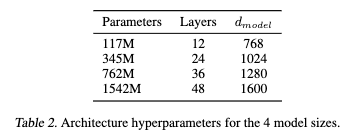

[출처 : https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf]

emergent abilities를 기대할 수 있는 foundation model로는 많이 부족한 감이 있죠.

위에서 살펴본 것처럼 단순한 Causal LM에 불과한 kogpt-2는 생성해 낼 문장의 품질을 디코딩 단계에서 인위적으로 조절해주는 방법 밖에 쓸 수 없습니다.  
하지만 RLHF를 kogpt-2에 적용한다면 더 좋은 문장을 생성해내는 방법을 모델이 스스로 학습해낼 수 있으리라 기대해 볼 수 있습니다.  
고도의 prompting은 어렵겠지만 현재 상태에서 특정 task에 fine-tuning했을 때보다는 성능이 한층 더 개선될 수 있지 않을까요?

kogpt-2에 RLHF를 적용하기기 위해선 새로운 데이터셋으로 일련의 재학습을 해줘야 합니다.  
그럼 각 단계별 모델 구현에 앞서 우리가 사용할 데이터셋을 확인해보도록 하겠습니다.

먼저 SFT를 시도할 initial 모델에 쓸 데이터셋을 살펴보겠습니다.

### 데이터셋 확인

In [17]:
import json
data_path_1_SFT = '/content/KoChatGPT/data_kochatgpt/kochatgpt_1_SFT.jsonl'
with open(data_path_1_SFT, "r", encoding='utf-8-sig') as json_file:
    list_data_dict = json.load(json_file)

print(len(list_data_dict))
list_data_dict[:3]

12000


[{'prompt': '불고기용 고기 한우에요?',
  'completion': "'저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하지만 일반적으로 불고기용 고기는 한우, 쇠고기, 돼지고기 등 다양한 종류의 고기를 사용합니다. 하지만 한우는 대표적인 고급 육류로 알려져 있기 때문에, 한우를 사용하는 경우도 많습니다. 알러지나 개별 건강 상태에 따라 다를 수 있으니 충분한 정보 수집 후에 선택해 주시기 바랍니다.",
  'tokens': 193},
 {'prompt': '쓰던 앱이 유료로 전환됐어',
  'completion': "'어떤 앱인지 모르기 때문에 정확한 답변을 드리기 어렵습니다. 하지만, 일반적으로 유료 전환된 앱은 기존 무료 앱에서 추가적인 기능이나 서비스를 제공하는 경우가 많습니다. 이 경우, 유료 전환 이전 가격이 매우 저렴하거나 무료인 경우가 많으므로, 앱을 계속 사용하려면 추가적인 비용을 지불해야 할 수 있습니다. 하지만, 유료 전환 이후에는 기존 사용자 또는 새로운 사용자 모두가 추가 기능과 높은 품질의 서비스를 이용할 수 있게 됩니다. 따라서, 앱 개발자는 유료 모델로 전환함으로써 앱의 수익을 증가시키고 더 나은 서비스를 제공할 수 있습니다.",
  'tokens': 288},
 {'prompt': '여친이랑 다툼',
  'completion': "'저는 인공지능이기 때문에 여친과의 다툼에 대해서는 조언을 드릴 수는 없습니다. 하지만 다투게 되면 상대방의 말을 경청하는 태도와 서로의 감정을 존중하는 것이 중요합니다. 논리적이고 차분한 대화를 통해 문제를 해결해보세요. 그리고 서로를 이해하고 서로의 의견을 수용하는 것이 중요합니다.",
  'tokens': 153}]

**Q6. kochatgpt_1_SFT 데이터셋의 prompt와 completion은 각각 어떻게 생성되었나요?  
그렇게 구축한 논리는 무엇인가요?**

<details>

A. 다양한 한국어 질문을 포함하는 데이터셋에서 질문을 수집하였으며, 여기에는 ChatbotData, AI허브의 한국어 대화 및 일반상식 데이터, KorQuad 등이 포함되어있습니다. 이 중 12,000개의 질문을 랜덤으로 추출하였습니다.

수집된 질문에 대한 답변을 생성하기 위해 ChatGPT를 활용하였으며 각 질문을 ChatGPT에 입력하여 자동으로 답변을 생성하였습니다.

사람이 직접 레이블링하는 대신 ChatGPT를 활용하여 대량의 질문-답변 데이터를 효율적으로 생성하였으며, 이를 통해 모델의 성능을 향상시키고자 하였습니다.

다음으로 RM에 사용할 데이터셋을 살펴보겠습니다.

In [18]:
data_path_2_RM = '/content/KoChatGPT/data_kochatgpt/kochatgpt_2_RM.jsonl'
with open(data_path_2_RM, "r", encoding='utf-8-sig') as json_file:
    list_data_dict = json.load(json_file)

print(len(list_data_dict))
list_data_dict[:3]

10220


[{'prompt': '번디는 자신이 탐정잡지, 범죄소설 그리고 성범죄 관련 실제 범죄 다큐멘터리들을 탐독했다고 누구에게 말했나?',
  'completion_0': 'Allow me to answer your question. I know that you are curious about me.',
  'completion_1': '번디는 다양한 인터뷰자들과 뉴스홍보 담당자들과의 면담 때 밝혔다.',
  'completion_2': '라이언에게 말했다.',
  'ranking': [2, 1, 0]},
 {'prompt': '개포주공아파트는 몇 단지로 이루어져 있나?',
  'completion_0': '개포주공아파트는 다섯 단지로 이루어져 있습니다.',
  'completion_1': '이날 목송에서 구글상위노',
  'completion_2': '개포주공아파트는 총 27개 단지로 이루어져 있습니다.',
  'ranking': [2, 0, 1]},
 {'prompt': '김영삼의 후보 시절 지역표심을 겨냥한 발언을 문제삼은 후보는?',
  'completion_0': 'The diameter of the Metallic domain is bigger than the Hyperonic domain.',
  'completion_1': '이 질문은 조금 불분명합니다. 김영삼 대통령이 후보 시절에 어떤 발언을 했고, 누가 그 발언을 문제삼았는지에 따라 답이 다를 수 있습니다.\\n\\n만약 김영삼 대통령이 후보 시절에 지역표심을 겨냥한 발언을 했다는 가정하에, 그 발언을 문제삼은 후보가 누구였는지를 대답하자면, 그 답은 이화선 당시 민주당 대통령 후보가 될 것입니다. 1992년 총선 때, 김영삼 대선후보는 "집값이 오른 노량진역 부근의 부동산 가격은 세월호 폭침 후 \\\'강남 도시재생\\\' 일환으로 상승했다"는 발언을 했습니다. 하지만 이화선 후보는 이 발언을 "전국적으로 경제적 발전이 이루어지지 않은 지방민의 마음을 멀리해지려는 무례한 발언"이라고 비판하며 문

**Q7. kochatgpt_2_RM 데이터셋의 prompt와 completion 그리고 ranking은 각각 어떻게 생성되었나요?  
그렇게 구축한 논리는 무엇인가요?**

<details>

A. kochatgpt_1_SFT 데이터셋에서 사용된 질문(prompt)을 재사용하여 데이터의 일관성을 유지하였고 ChatGPT 또는 다른 GPT 기반 모델을 사용하여 하나의 질문(Prompt)에 대해 여러 개의 답변(Completion) 을 생성하였습니다.

SFT(지도 학습)된 모델이 단순히 정해진 패턴을 따르는 것이 아니라, 강화학습 적용을 위해 사용자가 선호하는 답변을 생성하도록 진행하였습니다.

마지막으로 PPO 학습에 쓰일 데이터를 살펴보겠습니다.

In [19]:
data_path_3_PPO = '/content/KoChatGPT/data_kochatgpt/kochatgpt_3_PPO.jsonl'
with open(data_path_3_PPO, "r", encoding='utf-8-sig') as json_file:
    list_data_dict = json.load(json_file)

print(len(list_data_dict))
list_data_dict[:3]

12000


[{'prompt': '번디는 자신이 탐정잡지, 범죄소설 그리고 성범죄 관련 실제 범죄 다큐멘터리들을 탐독했다고 누구에게 말했나?'},
 {'prompt': '개포주공아파트는 몇 단지로 이루어져 있나?'},
 {'prompt': '김영삼의 후보 시절 지역표심을 겨냥한 발언을 문제삼은 후보는?'}]

**Q8. kochatgpt_3_PPO의 prompt는 어떻게 생성되었나요?  
그렇게 구축한 논리는 무엇인가요?**

<details>

A. kochatgpt_3_PPO 데이터셋의 Prompt는 kochatgpt_2_RM 데이터셋에서 사용된 질문(prompt)들을 기반으로 하였으며 RLHF에서 정책 모델(Policy Model) 을 학습시키기 위해 사용되었습니다.

# Supervised Fine-Tuning

### SFT
이번 스텝에서는 kogpt-2를 instruction dataset으로 SFT를 진행해 보겠습니다.

먼저 필요한 라이브러리들을 불러오겠습니다.

In [20]:
from typing import Optional, Dict, Sequence
from torch.utils.data import Dataset
from dataclasses import dataclass
import logging
import copy

다음으로 모델과 토크나이저를 불러오겠습니다.

In [21]:
model = AutoModelForCausalLM.from_pretrained('skt/kogpt2-base-v2')
from transformers import PreTrainedTokenizerFast
# [수정] AutoTokenizer는 transformers 5.x에서 byte-level(slow) GPT2Tokenizer로 풀려
# 한글이 바이트 단위로 쪼개진 ID로 학습됨 → 생성 결과가 깨지는 원인.
# fast 토크나이저로 고정해 학습~생성 전 구간의 ID 체계를 일치시킨다.
tokenizer = PreTrainedTokenizerFast.from_pretrained(
    'skt/kogpt2-base-v2', bos_token='</s>', eos_token='</s>', unk_token='</s>', pad_token='</s>',
    padding_side="right",
    model_max_length=512,
)

print(tokenizer)

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


TokenizersBackend(name_or_path='skt/kogpt2-base-v2', vocab_size=51200, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'bos_token': '</s>', 'eos_token': '</s>', 'unk_token': '</s>', 'pad_token': '</s>'}, added_tokens_decoder={
	0: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("<usr>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	4: AddedToken("<sys>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	5: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	6: AddedToken("<mask>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	7: AddedT

모델 인퍼런스 단계에서 사용할 prompt 딕셔너리 템플릿과 SFT 데이터셋 클래스를 정의하겠습니다.

In [22]:

class SFT_dataset(Dataset):

    def __init__(self, data_path_1_SFT: str, tokenizer: transformers.PreTrainedTokenizer, verbose=False):
        super(SFT_dataset, self).__init__()
        logging.warning("Loading data...")

        pattern_instruction = 'prompt'  # instruction
        pattern_output = 'completion'  # response

        with open(data_path_1_SFT, "r", encoding='utf-8-sig') as json_file:
            list_data_dict = json.load(json_file)

        PROMPT_DICT = {
            "prompt_input": (
                "### Instruction(명령어):\n{prompt}\n\n### Response(응답):"
            )
        }

        prompt_input = PROMPT_DICT["prompt_input"]

        sources = []
        for example in list_data_dict:
            tmp = prompt_input.format_map(example)
            sources.append(tmp)

        targets = []
        for example in list_data_dict:
            targets.append(f"{example[pattern_output]}{tokenizer.eos_token}")
        examples = [s + t for s, t in zip(sources, targets)]

        sources_tokenized = self._tokenize_fn(sources, tokenizer)  # source
        examples_tokenized = self._tokenize_fn(examples, tokenizer)  # source + target

        input_ids = examples_tokenized["input_ids"]
        labels = copy.deepcopy(input_ids)
        for label, source_len in zip(labels, sources_tokenized["input_ids_lens"]):
            label[:source_len] = -100

        data_dict = dict(input_ids=input_ids, labels=labels)

        self.input_ids = data_dict["input_ids"]
        self.labels = data_dict["labels"]
        logging.warning("Loading data done!!: %d"%(len(self.labels)))


    def _tokenize_fn(self, strings: Sequence[str], tokenizer: transformers.PreTrainedTokenizer) -> Dict:
        tokenized_list = [
            tokenizer(
                text,
                return_tensors="pt",
                padding="longest",
                max_length=tokenizer.model_max_length,
                truncation=True,
            )
            for text in strings
        ]
        input_ids = labels = [tokenized.input_ids[0] for tokenized in tokenized_list]
        input_ids_lens = labels_lens = [
            tokenized.input_ids.ne(tokenizer.pad_token_id).sum().item() for tokenized in tokenized_list
        ]
        return dict(
            input_ids=input_ids,
            labels=labels,
            input_ids_lens=input_ids_lens,
            labels_lens=labels_lens,
        )


    def __len__(self):
        return len(self.input_ids)


    def __getitem__(self, i) -> Dict[str, torch.Tensor]:
        return dict(input_ids=self.input_ids[i], labels=self.labels[i])

**Q9. SFT_dataset 클래스의 이니셜라이저에서 label[:source_len] = -100 코드의 -100이 의미하는 게 무엇인가요?  
해당 코드가 필요한 이유와 그 기능은 무엇인가요?**

<details>

A. 다음 링크를 참고해보세요.  
https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html

In [23]:
@dataclass
class DataCollatorForSupervisedDataset(object):

    tokenizer: transformers.PreTrainedTokenizer

    def __call__(self, instances: Sequence[Dict]) -> Dict[str, torch.Tensor]:
        input_ids, labels = tuple([instance[key] for instance in instances] for key in ("input_ids", "labels"))
        input_ids = torch.nn.utils.rnn.pad_sequence(
            input_ids, batch_first=True, padding_value=self.tokenizer.pad_token_id
        )
        labels = torch.nn.utils.rnn.pad_sequence(labels, batch_first=True, padding_value= -100)
        return dict(
            input_ids=input_ids,
            labels=labels,
            attention_mask=input_ids.ne(self.tokenizer.pad_token_id),
        )

**Q10. DataCollatorForSupervisedDataset 클래스에서  labels = torch.nn.utils.rnn.pad_sequence(labels, batch_first=True, padding_value= -100) 코드의 padding_value= -100 인자의 -100은 어떤 기능을 하나요?**

<details>

A. padding_value=-100는 시퀀스 패딩을 수행할 때, 패딩된 레이블의 값으로 -100을 사용한다는 의미입니다. 이는 모델의 출력과 비교할 때 실제 의미 있는 토큰에 대해서만 손실을 계산하고, 패딩된 부분은 계산에서 제외하도록 하기 위해 사용됩니다.

이제 SFT_dataset 클래스를 사용해 훈련셋을 만들고 data collator 인스턴스를 만들겠습니다.

In [24]:
train_dataset = SFT_dataset(data_path_1_SFT='/content/KoChatGPT/data_kochatgpt/kochatgpt_1_SFT.jsonl', tokenizer=tokenizer)
data_collator = DataCollatorForSupervisedDataset(tokenizer=tokenizer)

print('input : %s'%train_dataset.input_ids[0])
print('output: %s'%train_dataset.labels[0])

input : tensor([  739,   378,   378,   378, 14659, 13394, 37091, 10651,   383, 25841,
         8006, 14914,   375,  7673, 20479,  8091, 22311,  9036, 30902, 13675,
          375,   378,   378,   378, 41951,   454,  9549, 20549,   383,  8142,
         7192, 14914,   382, 37767, 13753,  8263,  7166,   739,  8352,  7659,
         9594, 25585, 13600,  8022,  9378, 11532,  9887, 11218,  9111, 16691,
        10351, 10561,  9128, 20479,  8091,  9065,  9446,  9036, 28420, 26521,
        10163, 26367,  6958,  9030,  9882, 12317, 25882,  9209, 37194, 10351,
         9036, 12168, 10529, 15989,  9719, 15434, 10552, 11188, 13362,  9036,
        15805, 11300, 11846,  9146, 16691,  9181,  7397, 15806, 13480, 11342,
        17596,  9161, 19996,  9025, 25006, 18595,  9966, 12592, 10751, 11814,
         8711,  9046, 12450,  9117,  7377, 12521,     1])
output: tensor([ -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
         -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -10

**Q11. 아래 코드블럭에 train_dataset.input_ids[0] 와 train_dataset.labels[0] 를 디코딩하는 함수를 작성하여 정수토큰들의 인코딩전 원래 문장이 어떤 형태로 토크나이징 되었는지 확인해보세요.**

<details>

A. 다른 분들의 결과와 비교해볼까요?😙

In [25]:
# train_dataset.input_ids[0]를 디코딩해보세요.

훈련을 위한 마지막 단계로 Training arguments를 사용해 trainer 클래스를 정의하겠습니다.

In [26]:
training_args = transformers.TrainingArguments(
    output_dir="/content/test",
    num_train_epochs=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=5,
    prediction_loss_only=True,
    fp16 = True
    )
trainer = transformers.Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=train_dataset
)

**Q12. [허깅페이스의 Trainer 클래스 다큐먼트](https://huggingface.co/docs/transformers/v4.28.1/en/main_classes/trainer#transformers.TrainingArguments)를 참고해
위 코드블럭의 TrainingArguments의 인자들이 각각 어떤 기능을 하는지 찾아보세요.  
그리고 변경 및 추가 가능한 학습옵션에는 어떤 것들이 있는지 살펴보세요.**

<details>

A. 주요 기능

- **output_dir** : 모델, 체크포인트, 로그 등 모든 결과물을 저장할 경로를 지정합니다.
  
- **per_device_train_batch_size / per_device_eval_batch_size** : 각 디바이스(GPU/CPU)에서 사용하는 배치 사이즈로, 학습 속도와 메모리 사용량에 큰 영향을 줍니다.

- **learning_rate** : 학습의 시작 속도를 결정하는 핵심 하이퍼파라미터로, 모델 성능에 직접적인 영향을 미칩니다.

- **num_train_epochs / max_steps** : 학습의 총 반복 횟수를 결정합니다. `max_steps`가 설정되면 `num_train_epochs`는 무시되므로, 둘 중 하나만 신경 쓰면 됩니다.

- **warmup_steps / warmup_ratio** : 학습 초기 안정화를 위해 학습률을 서서히 증가시키는 단계로, 옵티마이저의 성능과 학습 안정성에 도움을 줍니다.

- **evaluation_strategy** : 학습 도중 평가를 수행하는 빈도를 결정합니다. (예: `"steps"` 또는 `"epoch"`)  
  - _주의_: 너무 잦은 평가가 학습 속도를 늦출 수 있으니 적절한 주기를 선택해야 합니다.

- **save_steps** : 체크포인트 저장 주기를 정합니다. 디스크 사용량과 복구 지점을 고려할 때 중요한 옵션입니다.

- **logging_steps** : 학습 진행 상황을 기록할 주기를 설정합니다. 디버깅이나 모니터링에 필수적입니다.

- **fp16** : 16비트 부동소수점 연산(FP16)을 활성화해 메모리 사용량과 학습 속도를 최적화할 수 있습니다. 다만, 모든 환경에서 안정적인 결과를 보장하지 않을 수 있으니 주의가 필요합니다.

SFT 훈련을 진행해볼까요? (빠르게 학습해보기 위해 1epoch만 돌려보도록 하겠습니다.)

In [27]:
trainer.train()
model.save_pretrained('/content/output_1_SFT')

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
500,2.975666
1000,2.782682
1500,2.684779


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

loss가 잘 줄어들었나요?  
이제 문장 생성 능력을 확인하기 위해 빠르게 허깅페이스의 pipleline 클래스를 사용하여 generator를 만들어보겠습니다.

In [28]:
generator = transformers.pipeline('text-generation', model='/content/output_1_SFT', tokenizer=tokenizer)

generation_args = dict(
    num_beams=4,
    repetition_penalty=2.0,
    no_repeat_ngram_size=4,
    eos_token_id=375, # \n
    max_new_tokens=64,
    do_sample=True,
    top_k=50,
    early_stopping=True
)

PROMPT_DICT = {
    "prompt_input": (
        "### Instruction(명령어):\n{prompt}\n\n### Response(응답):"
    )
}

list_prompt = ['불고기용 고기 한우에요?',
               '리처드 닉슨이 43대 부통령직을 수행한 년도는?',
               '시카고 오헤어 국제공항은 어디에 있어?',
               '오늘 미세먼지 어때?']

list_prompt = [PROMPT_DICT['prompt_input'].format_map({'prompt' : tmp}) for tmp in list_prompt]

list_result = generator(list_prompt, **generation_args)
for prompt, result in zip(list_prompt, list_result):
    print()
    print((result[0]['generated_text']))

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'eos_token_id', 'top_k', 'early_stopping', 'repetition_penalty', 'num_beams', 'max_new_tokens', 'do_sample', 'no_repeat_ngram_size'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=64) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even


### Instruction(명령어):
불고기용 고기 한우에요?

### Response(응답):'저는 인공지능 어시스턴트이기 때문에 고기를 먹을 수는 없습니다. 하지만 일반적으로 불고기용 고기는 보통 쇠고기, 돼지고기, 닭고기 등 다양한 부위를 사용합니다. 따라서 어떤 종류의 고기를 원하시는지 알려주시면 더 정확한 답변을 드릴 수 있을 것 같습니다. 감사합니다.

### Instruction(명령어):
리처드 닉슨이 43대 부통령직을 수행한 년도는?

### Response(응답):'리처드 닉슨은 41대 부통령직을 수행했습니다. J.R. 롤링 (James D. Rolling)은 46대 부통령직을 역임하였습니다. J. R. 롤링은 47대 부통령직을 맡았습니다. J. L. 롤링은 54대 부통령직을 맡았던 인물 중 한 명입니다. J.

### Instruction(명령어):
시카고 오헤어 국제공항은 어디에 있어?

### Response(응답):'저는 인공지능 어시스턴트이기 때문에 시카고에 대한 정보를 가지고 있지 않습니다. 하지만 시카고는 미국 캘리포니아주 샌프란시스코에 위치해 있습니다. 따라서 시카고에 대한 정보는 해당 항공사의 공식 웹사이트나 고객센터를 통해 확인하실 수 있을 것 같습니다!立航空館, Japanes

### Instruction(명령어):
오늘 미세먼지 어때?

### Response(응답):'저는 인공지능 챗봇이기 때문에 미세먼지 정보를 알 수 없습니다. 하지만, 미세먼지 예보 앱을 통해 미세먼지 농도를 확인해보시는 것을 추천드립니다. 또한, 미세먼지 농도가 높은 날에는 야외 활동을 자제하는 것이 좋습니다. 또한, 미세먼지가 심한 날에는 마스크를


**Q13. [허깅페이스의 Text generation strategies](https://huggingface.co/docs/transformers/v4.28.1/en/generation_strategies)를 참고해
generation_args에 있는 각 옵션의 기능을 확인하세요.  
변경하거나 추가할 수 있는 옵션에는 어떤 것들이 있는지 살펴보세요.**

<details>

A. 주요 Generation Options

- **max_length** : 생성할 텍스트의 최대 길이를 지정합니다. 단, 너무 큰 값은 불필요한 계산을 유발할 수 있습니다.

- **min_length** : 생성 텍스트의 최소 길이를 보장합니다.

- **do_sample** : 샘플링을 사용할지 여부를 결정합니다. `False`일 경우 greedy search 혹은 beam search 등 결정론적 방법을 사용합니다.

- **num_beams** : beam search 시 고려할 빔의 수를 지정합니다. 값이 클수록 더 다양한 후보를 고려하지만, 계산 비용이 증가합니다.

- **temperature** : 샘플링 시 확률 분포의 평탄화 정도를 조절합니다. 낮은 값은 확률 분포를 예리하게 만들어, 높은 값은 다양성을 증가시킵니다.

- **top_k** : 샘플링 시 고려할 상위 k개의 후보 토큰만 사용합니다. 높은 값은 다양한 결과를, 낮은 값은 집중된 선택을 유도합니다.

- **top_p (nucleus sampling)** : 확률 누적 합이 p에 도달할 때까지의 후보 토큰을 사용합니다. 후보 집합의 크기를 동적으로 조절해, 확률이 낮은 토큰은 배제합니다.

- **repetition_penalty** : 동일한 문구나 단어의 반복 생성을 방지합니다. 값이 1보다 크면 반복에 패널티를 부여합니다.

- **length_penalty** : beam search 시 문장 길이에 대한 보정을 합니다. 값이 1보다 크면 긴 문장을 선호, 작으면 짧은 문장을 선호합니다.

- **no_repeat_ngram_size** : 지정한 크기의 n-그램이 반복되지 않도록 합니다. 예를 들어, 3을 설정하면 동일한 3-그램이 여러 번 등장하지 않습니다.

- **early_stopping** : 모든 beam에서 EOS 토큰이 생성되면 조기 종료합니다.

- **bad_words_ids** : 생성 과정에서 금지된 단어들의 토큰 ID 리스트를 지정하여, 해당 단어들이 생성되지 않도록 합니다.

- **forced_bos_token_id / forced_eos_token_id** : 생성된 텍스트의 시작 혹은 종료 토큰을 강제합니다.

- **output_scores / return_dict_in_generate** : 생성 과정의 자세한 정보를 반환할지 여부를 결정합니다. 디버깅이나 후처리를 위해 사용됩니다.

SFT 모델의 성능은 어떤가요?  
SFT 단계를 최적화하기 위해선 무엇보다도 instruction dataset의 품질과 initial모델의 언어모델링 성능이 중요합니다.  
GPT를 새로 pretrain 하여 언어모델 성능을 도약시키는 일은 우리의 학습목표를 넘어서는 일이니 우선은 데이터셋 전처리를 더 수행하고 최상의 디코딩 전략이 적용된 generator를 설계한다면 더 나은 성능을 기대해 볼 수 있을 것입니다.  
하지만 지금은 baseline을 빠르게 돌려보는 게 목적입니다.  
이제 다음 단계인 reward modeling으로 넘어가 보도록 하겠습니다.

메모리 관리를 위해 캐시를 비우고 넘어가겠습니다.

In [29]:
torch.cuda.empty_cache()

# Reward Model
이번 스텝에서는 RLHF의 두번째 단계인 Reward model을 설계하고 학습해보겠습니다.  
필요한 라이브러리들을 불러와 볼까요?

### RM

In [30]:
from chatgpt.dataset import RewardDataset
from chatgpt.models.base import RewardModel
from chatgpt.trainer.strategies import NaiveStrategy
from chatgpt.trainer.rm import RewardModelTrainer

from transformers.models.gpt2.configuration_gpt2 import GPT2Config
from transformers.models.gpt2.modeling_gpt2 import GPT2Model

import torch.nn as nn

import random

Import된 라이브러리들을 보면 SFT단계에서 사용했던 것과는 다른 모듈들이 몇 개 눈에 띕니다.  
우선 chatgpt 폴더 안에 있는 RM 관련 모듈들이 눈에 띄네요.
NaiveStrategy라는 모듈도 있습니다.  
원본 깃헙 레포짓에는 multi GPU를 사용해서도 KoChatGPT를 실습해볼 수 있도록 하고 있지만 우리는 single GPU를 사용해야 하는 환경이므로 학습전략을 고정시켜놓기 위해 해당 모듈을 따로 import했습니다.  
마지막엔 허깅페이스의 transformers에서 gpt2 모델 관련 모듈들도 사용하고 있네요.

**Q. Q14. SFT 모델의 출력 결과를 Reward model이 받아 어떻게 처리하게 되는지 잠시 생각해봅시다.  
여기서 Reward model로 GPT2를 사용하는 이유가 무엇일까요?**

<details>

A. GPT-2를 Reward Model로 선택하는 이유는 다음과 같습니다.

1. 사전 학습(pretraining)의 이점  
    GPT-2는 대규모 텍스트 데이터에 대해 사전 학습되어 다양한 언어 패턴과 문맥 정보를 이미 학습한 상태입니다. 이를 통해, SFT 모델이 생성한 텍스트에 대해 미세하게 언어적, 문맥적 평가를 수행할 수 있습니다.
2. 아키텍처의 유사성 및 일관성  
    SFT 모델이 Transformer 기반이라면, GPT-2 역시 같은 Transformer 아키텍처를 사용합니다. 이로 인해 두 모델 간의 표현 공간이 어느 정도 일치할 가능성이 있으며, 텍스트의 흐름이나 품질을 평가하는 데 있어 더 자연스러운 비교가 가능해집니다.
3. 효율성과 구현 용이성  
    GPT-2는 오픈 소스 커뮤니티에서 널리 사용되고 검증된 모델로, 리소스나 구현 측면에서 안정적입니다. 따라서 복잡한 Reward Model을 처음부터 구축하기보다는, GPT-2를 기반으로 미세 조정하여 활용하는 것이 효율적입니다.
4. 자연스러운 텍스트 생성 및 평가  
    GPT-2는 이미 언어 생성 능력이 뛰어나므로, 생성된 텍스트의 문법적, 의미적 적합성을 평가할 때 신뢰성 있는 피드백을 제공할 수 있습니다.

이제 Reward model을 설계해 볼까요?
GPTRM_custom 이라는 이름으로 클래스를 선언하겠습니다.

In [31]:
class GPTRM_custom(RewardModel):

    def __init__(self,
                 pretrained: Optional[str] = None,
                 config: Optional[GPT2Config] = None,
                 checkpoint: bool = False,
                 lora_rank: int = 0,
                 lora_train_bias: str = 'none',
                 tokenizer=None) -> None:
        if pretrained is not None:
            model = GPT2Model.from_pretrained(pretrained)
            model.resize_token_embeddings(len(tokenizer))
        elif config is not None:
            model = GPT2Model(config)
        else:
            model = GPT2Model(GPT2Config())
        if checkpoint:
            model.gradient_checkpointing_enable()

        value_head = nn.Linear(model.config.n_embd, 1)
        super().__init__(model, value_head, lora_rank, lora_train_bias)

        if pretrained is not None:
            self.model = model
            self.pretrained = pretrained


    def save_pretrained(self, dir):
        if self.pretrained is not None:
            self.model.save_pretrained(dir)

위 클래스의 원본 코드는 [이 링크](https://github.com/hpcaitech/ColossalAI/blob/2e16f842a9e5b1fb54e7e41070e9d2bb5cd64d7c/applications/ChatGPT/chatgpt/nn/gpt_rm.py)에서 확인하실 수 있습니다.

여기서 주의깊게 봐야할 부분은 이니셜라이저의 value_head = nn.Linear(model.config.n_embd, 1) 코드입니다.

**Q15. nn.Linear() 레이어의 인자로 model.config.n_embd와 1이 주어졌습니다.  
model.config.n_embd는 무엇이고 1은 왜 입력된 것일까요?**

<details>

A.
- model.config.n_embd: GPT-2의 내부 은닉 상태 벡터의 차원(예: 768, 1024 등).  
- 1: 최종적으로 하나의 보상 값(스칼라)을 출력하기 위한 차원.

이제 SFT에서와 마찬가지로 사용할 모델과 토크나이저를 불러오겠습니다.
with구문의 NaiveStrategy()는 chatgpt/trainer/strategies 폴더의 base 모듈에서 정의된
Strategy클래스를 상속한 NaiveStrategy클래스입니다.

In [32]:
model = AutoModelForCausalLM.from_pretrained('skt/kogpt2-base-v2')
from transformers import PreTrainedTokenizerFast
# [수정] AutoTokenizer는 transformers 5.x에서 byte-level(slow) GPT2Tokenizer로 풀려
# 한글이 바이트 단위로 쪼개진 ID로 학습됨 → 생성 결과가 깨지는 원인.
# fast 토크나이저로 고정해 학습~생성 전 구간의 ID 체계를 일치시킨다.
tokenizer = PreTrainedTokenizerFast.from_pretrained(
    'skt/kogpt2-base-v2', bos_token='</s>', eos_token='</s>', unk_token='</s>', pad_token='</s>',
    padding_side="right",
    model_max_length=512,
)

with NaiveStrategy().model_init_context():
        model = GPTRM_custom(pretrained='skt/kogpt2-base-v2', lora_rank=0, tokenizer=tokenizer).cuda()

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] GPT2Model LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 
lm_head.weight                          | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


다음으로 RM을 훈련시킬 때 사용할 ranking dataset을 만들어보겠습니다.

In [33]:
with open('/content/KoChatGPT/data_kochatgpt/kochatgpt_2_RM.jsonl', "r", encoding='utf-8-sig') as json_file:
    list_data_dict = json.load(json_file)

total_data_ranking2chosen = []
for tmp in list_data_dict:
    one_data_ranking2chosen = []

    data = {}
    data['prompt'] = tmp['prompt']
    if tmp['ranking'][0] < tmp['ranking'][1]:
        data['chosen'] = tmp['completion_0']
        data['rejected'] = tmp['completion_1']
    else:
        data['chosen'] = tmp['completion_1']
        data['rejected'] = tmp['completion_0']
    one_data_ranking2chosen.append(data)

    data = {}
    data['prompt'] = tmp['prompt']
    if tmp['ranking'][0] < tmp['ranking'][2]:
        data['chosen'] = tmp['completion_0']
        data['rejected'] = tmp['completion_2']
    else:
        data['chosen'] = tmp['completion_2']
        data['rejected'] = tmp['completion_0']
    one_data_ranking2chosen.append(data)

    data = {}
    data['prompt'] = tmp['prompt']
    if tmp['ranking'][1] < tmp['ranking'][2]:
        data['chosen'] = tmp['completion_1']
        data['rejected'] = tmp['completion_2']
    else:
        data['chosen'] = tmp['completion_2']
        data['rejected'] = tmp['completion_1']
    one_data_ranking2chosen.append(data)



    total_data_ranking2chosen.extend(one_data_ranking2chosen)

print('before data num: %d'%(len(list_data_dict)))
print('after  data num: %d'%(len(total_data_ranking2chosen)))
print('data example: \n%s'%total_data_ranking2chosen[45])

before data num: 10220
after  data num: 30660
data example: 
{'prompt': '애플은 리사를 어떻게 처리했어', 'chosen': '애플이 누구인지 명확히 알 수 없어서, 리사가 누구인지와 어떤 상황에서 처리되었는지에 대한 추가적인 정보가 필요합니다. 따라서, 보다 정확한 답변을 제공할 수 없습니다.', 'rejected': '애플은 리사를 위해 고객 서비스 부서에서 고객 다양한 컴퓨터 관련 문제에 대해 응답하는 데 필요한 모든 지원을 제공했습니다. 사용자가 하드웨어 문제를 경험할 때, 전문가들은 필요한 수리(수리, 추가 부품 제공, 소프트웨어 업그레이드 등)을 제공해 드릴 수 있습니다. 또한, 사용자가 사용 방법 문제나 기타 문제를 경험할 때, 대화 상대로 사용자를 지원할 수 있는 전문 고객 서비스 직원들이 사용자에게 상담하고 도움을 주는 데 도움이 될 수 있는 정보를 제공합니다. 또한, 인터넷에서 제공되는 정보를 통해 문제를 해결하거나 고객 서비스 웹 사이트를 통해 자신의 문제를 진단할 수 있도록 하는 등 다양한 방법으로 리사를 처리해 왔습니다.'}


kochatgpt_2_RM.jsonl 은
chatGPT, davinch, ada 세개 모델에 같은 prompt를 주고 얻은 세 답변을
순서대로 good, bad, worst로 간주해
순서를 뒤섞어 completion_0, completion_1, completion_2 세 키에 할당하여 만든 데이터셋입니다.
위와 같이 코드를 짜게 되면 chosen과 resjected에 각각
completion_0, completion_1, completion_2 세개 답변이 가능한 모든 조합으로 들어가게 되어
chosen에 worst 답변이 들어가고
rejected에 good답변이 들어간 데이터도 만들어집니다.

위와 같이 ranking dataset을 만들면 RM의 loss는 어떻게 계산이 되는 걸까요?
RM의 loss function은 pairwiseloss라는 이름으로 설계되어 있습니다.
아래 pairwiseloss 코드를 첨부했습니다.
원본 코드는 chatgpt/models 폴더의 loss.py 를 확인해보세요.

```python
class PairWiseLoss(nn.Module):

    def forward(self, chosen_reward: torch.Tensor, reject_reward: torch.Tensor) -> torch.Tensor:
        probs = torch.sigmoid(chosen_reward - reject_reward)
        log_probs = torch.log(probs)
        loss = -log_probs.mean()
        return loss
```



**Q16. 위 코드블럭에서 probs = torch.sigmoid(chosen_reward - reject_reward) 코드를 찾아보세요.  
chosen_reward - reject_reward 식은 어떤 연산을 의미하나요?  
loss = -log_probs.mean() 코드는 무엇을 최대화하는 연산으로 해석할 수 있을까요?**

<details>

A. `chosen_reward - reject_reward`는 선택된(chosen) 보상과 거부된(reject) 보상 간의 차이를 계산하는 연산입니다. 이 차이가 클수록 선택된 샘플이 거부된 샘플보다 높은 보상을 받았다는 것을 의미하죠.

여기서 `torch.sigmoid(chosen_reward - reject_reward)`를 적용하면, 두 보상의 차이를 확률 값(0과 1 사이)으로 변환하게 됩니다. 이 확률 값은 선택된 샘플이 거부된 샘플보다 더 좋은 결과를 낼 확률로 해석할 수 있습니다.

`loss = -log_probs.mean()` 코드는 선택된 샘플이 거부된 샘플보다 더 좋은 결과를 내는 log 확률을 최대화하는 방향으로 작동합니다.



```python
total_data_ranking2chosen = []

for tmp in list_data_dict:
     prompt = tmp['prompt']
     ranking = tmp['ranking']

     for index in range(1, len(ranking)):
         n = ranking[0]
         m = ranking[index]


         data = {
             'prompt': prompt,
             'chosen': tmp['completion_{}'.format(n)],
             'rejected': tmp['completion_{}'.format(m)]
         }

         total_data_ranking2chosen.append(data)
```



**Q17. 위 코드대로 ranking dataset 함수를 수정하게 되면 ranking data가 어떻게 만들어지게 되나요?  
둘의 차이를 비교하고 어떤 데이터셋을 사용하는게 더 적절한지 이야기해봅시다.**

<details>

A.  
원래 코드 (단순 ranking2chosen)

- ranking의 첫 번째 후보(최고 순위)를 항상 chosen으로 사용하고, 나머지 후보들을 rejected로 하는 방식입니다.
- 예를 들어, ranking이 [A, B, C]라면 (A가 최고라고 가정)
    - (prompt, chosen=A, rejected=B)
    - (prompt, chosen=A, rejected=C)
- 즉, 각 프롬프트당 2개의 pair가 생성됩니다.
비교 코드 (전체 쌍 생성):

- 후보들 간의 모든 쌍을 비교하여, 각 pair마다 어느 쪽이 더 좋은지 ranking 값을 비교합니다.
- ranking이 [A, B, C]라면
    - (prompt, chosen=A, rejected=B)
    - (prompt, chosen=A, rejected=C)
    - (prompt, chosen=B, rejected=C)
- 즉, 각 프롬프트당 3개의 pair가 생성됩니다.

만약 데이터의 ranking이 신뢰할 수 있고, 후보들 간의 미세한 차이를 모델이 잘 반영해야 한다면, 전체 쌍 생성 방식이 더 풍부한 학습 신호를 제공할 수 있습니다.  
반면에, 노이즈나 불확실성이 큰 데이터라면, 단순히 최고 후보와의 비교만 사용하는 것이 더 안정적일 수 있습니다.

이제 완성한 ranking dataset을 shuffle한 후 훈련셋을 만들어보겠습니다.  
빠르게 돌려보기 위해 전체 데이터중 일부만 학습하도록 하겠습니다.

In [34]:
import random
random.seed(230319)
random.shuffle(total_data_ranking2chosen)
print(total_data_ranking2chosen[45])

{'prompt': '유아인이 류승완 감독을 만나 영화 베테랑의 시나리오를 받았던 곳은?', 'chosen': '유아인이 류승완 감독을 만나 영화 베테랑의 시나리오를 받았던 곳은 류승완의 사무실입니다.', 'rejected': '대구 영화사옥'}


In [35]:
train_data = total_data_ranking2chosen[:1000]
eval_data = total_data_ranking2chosen[1000:1200]

print(len(train_data))
print(len(eval_data))

train_dataset = RewardDataset(train_data, tokenizer, 512)
eval_dataset = RewardDataset(eval_data, tokenizer, 512)

1000
200


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

**Q18. RewardDataset 클래스는 어떤 기능을 수행하나요?  
chatgpt/dataset폴더 내의 reward_dataset모듈을 참고해 답해보세요.**

<details>

A.
- 입력 데이터 처리
    각 데이터 항목은 prompt, chosen, rejected와 같은 키를 가지며, 이 클래스는 해당 텍스트들을 받아서 모델 학습에 적합한 형식으로 변환합니다.

- 토큰화(tokenization)
    주어진 토크나이저(tokenizer)를 사용하여 텍스트를 토큰 ID 시퀀스로 변환하고, 최대 길이(여기서는 512)로 잘라내거나 패딩(padding)을 적용합니다.

- 데이터셋 생성
    전처리된 데이터를 PyTorch의 Dataset 형식(예: torch.utils.data.Dataset)으로 만들어, Trainer 등에서 배치 단위로 데이터를 불러올 수 있도록 합니다.

데이터셋이 잘 만들어졌는지 하나를 뽑아 확인해봅시다.

In [36]:
idx = 1
print('#'*70)
print('## prompt ##')
print(train_data[idx]['prompt'])
print('#'*70)
print('## chosen ##')
print(train_data[idx]['chosen'])
print('#'*70)
print('## rejected ##')
print(train_data[idx]['rejected'])

######################################################################
## prompt ##
흑고래의 무게는 어느 정도야
######################################################################
## chosen ##
흑고래의 평균 몸무게는 약 25~40톤 정도이지만, 최대 몸무게는 50톤 이상에 이를 수 있습니다.
######################################################################
## rejected ##
흑고래의 무게는 매우 다양하게 달라집니다. 약 200kg에서 10톤까지 달라질 수 있습니다.


마지막으로 RM을 학습해 보겠습니다.

(SFT 훈련때와 마찬가지로 RM 훈련시 많은 자원이 소모됩니다.  
모델 체크포인트를 활용할 수 있으니, 각각의 모델을 더 많은 데이터로 더 오래 훈련하고자 할 시, 커널을 초기화 한 후 재학습을 해보세요.  
지금은 빠르게 학습해보기 위해 1epoch만 돌려보도록 하겠습니다)

In [37]:
trainer = RewardModelTrainer(model=model,
                             strategy=NaiveStrategy(),
                             optim=torch.optim.Adam(model.parameters(), lr=5e-5),
                             train_dataset=train_dataset,
                             eval_dataset=eval_dataset,
                             batch_size=4,
                             max_epochs=1)

In [38]:
trainer.fit(use_lora=0)

model.save_pretrained('/content/output_2_RM')

Train epoch:   0%|          | 0/1 [00:00<?, ?it/s]

Train step of epoch 0:   0%|          | 0/250 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

RM 학습이 잘 되었는지 확인해보기 위해 임의의 문장을 입력한 후 적절한 reward score를 출력하는지 살펴보도록 하겠습니다.

In [39]:
def inference_RM(input_text):
    input_ids = tokenizer.encode(input_text, return_tensors='pt').cuda()
    output = model(input_ids)
    output_reward = output.cpu().detach().numpy()[0]

    print('input: %s\nreward score: %.1f'%(input_text, output_reward))

    return output_reward

input_text = '인공지능은 똥멍청이 입니다'
output_reward = inference_RM(input_text=input_text)

input: 인공지능은 똥멍청이 입니다
reward score: -1.0


In [40]:
input_text = '인공지능(AI)은 컴퓨터에서 음성 및 작성된 언어를 보고 이해하고 번역하고 데이터를 분석하고 추천하는 기능을 포함하여 다양한 고급 기능을 수행할 수 있는 일련의 기술입니다.'

output_reward = inference_RM(input_text=input_text)

input: 인공지능(AI)은 컴퓨터에서 음성 및 작성된 언어를 보고 이해하고 번역하고 데이터를 분석하고 추천하는 기능을 포함하여 다양한 고급 기능을 수행할 수 있는 일련의 기술입니다.
reward score: -0.7


In [41]:
input_text = "인공지능(AI)은 컴퓨터에서 음성 및 작성된 언어를 보고 이해하고 번역하고 데이터를 분석하고 추천하는 기능을 포함하여 다양한 고급 기능을 수행할 수 있는 일련의 기술입니다. AI는 현대적인 컴퓨팅 혁신에서 중추적인 역할을 하며 개인과 비즈니스의 가치를 창출합니다. 예를 들어 광학 문자 인식(OCR)은 AI를 사용해 이미지 및 문서에서 텍스트 및 데이터를 추출하고, 구조화되지 않은 콘텐츠를 비즈니스에 바로 사용할 수 있게 만들고, 유용한 정보를 창출합니다."

output_reward = inference_RM(input_text=input_text)

input: 인공지능(AI)은 컴퓨터에서 음성 및 작성된 언어를 보고 이해하고 번역하고 데이터를 분석하고 추천하는 기능을 포함하여 다양한 고급 기능을 수행할 수 있는 일련의 기술입니다. AI는 현대적인 컴퓨팅 혁신에서 중추적인 역할을 하며 개인과 비즈니스의 가치를 창출합니다. 예를 들어 광학 문자 인식(OCR)은 AI를 사용해 이미지 및 문서에서 텍스트 및 데이터를 추출하고, 구조화되지 않은 콘텐츠를 비즈니스에 바로 사용할 수 있게 만들고, 유용한 정보를 창출합니다.
reward score: -0.6


In [42]:
input_text = "인공지능은 일반적으로 인간의 지능이 필요하거나 인간이 분석할 수 있는 것보다 규모가 큰 데이터를 포함하는 방식으로 추론, 학습 및 행동할 수 있는 컴퓨터 및 기계를 구축하는 것과 관련된 과학 분야입니다. AI는 컴퓨터 공학, 데이터 분석 및 통계, 하드웨어 및 소프트웨어 엔지니어링, 언어학, 신경 과학은 물론 철학과 심리학을 포함하여 여러 학문을 포괄하는 광범위한 분야입니다. 비즈니스의 운영 수준에서 AI는 주로 머신러닝과 딥 러닝을 기반으로 하는 기술 모음으로, 데이터 분석, 예상 및 예측, 객체 분류, 자연어 처리, 추천, 지능형 데이터 가져오기 등을 수행할 수 있습니다."

output_reward = inference_RM(input_text=input_text)

input: 인공지능은 일반적으로 인간의 지능이 필요하거나 인간이 분석할 수 있는 것보다 규모가 큰 데이터를 포함하는 방식으로 추론, 학습 및 행동할 수 있는 컴퓨터 및 기계를 구축하는 것과 관련된 과학 분야입니다. AI는 컴퓨터 공학, 데이터 분석 및 통계, 하드웨어 및 소프트웨어 엔지니어링, 언어학, 신경 과학은 물론 철학과 심리학을 포함하여 여러 학문을 포괄하는 광범위한 분야입니다. 비즈니스의 운영 수준에서 AI는 주로 머신러닝과 딥 러닝을 기반으로 하는 기술 모음으로, 데이터 분석, 예상 및 예측, 객체 분류, 자연어 처리, 추천, 지능형 데이터 가져오기 등을 수행할 수 있습니다.
reward score: -0.5


input text가 더 좋아질수록 reward score가 점진적으로 상승하나요?  
각 reward score 값이 적절해 보이시나요?  
reward score가 음수가 된다는 건 어떤 의미일까요?  
그 전에 reward score가 음수도 될 수 있도록 하려면 어떻게 해야 할까요?  
RM의 출력인 reward score가 scalar가 되도록 하는 게 왜 중요할까요?  

RLHF의 마지막 단계인 PPO 학습을 통해 살펴보도록 하겠습니다.

여기서도 메모리 관리를 위해 한 번더 캐시를 비우고 넘어가겠습니다.

In [43]:
torch.cuda.empty_cache()

# Proximal Policy Optimization

### PPO
드디어 RLHF의 마지막 세번째 단계인 PPO를 실습해볼 차례입니다.  
사용할 라이브러리들을 불러오도록 하겠습니다.

In [44]:
from chatgpt.models.gpt import GPTActor, GPTCritic
from chatgpt.trainer import PPOTrainer

from copy import deepcopy

노드에서 소개하는 KoChatGPT의 경우 PPO에 사용할 actor모델은 1단계 SFT 모델을, critic모델은 2단계 RM 모델을 사용합니다.

그리고 actor 모델이 critic 모델로부터 피드백을 받아 파라미터를 업데이트 할 때 적절한 페널티를 줄 수 있도록 하는 initial model은 SFT모델을 그대로 freezing 하여 사용합니다.

토크나이저는 pretrain 모델인 kogpt-2의 토크나이저를 그대로 사용해야겠죠?

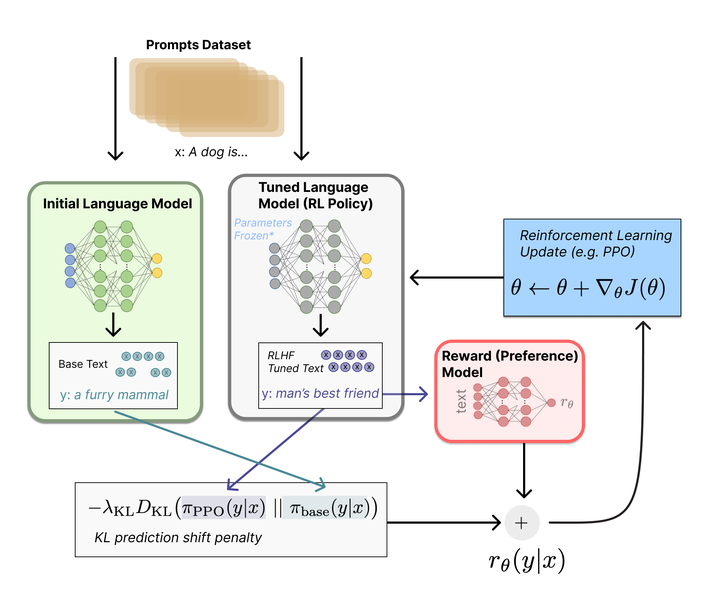

In [45]:
with NaiveStrategy().model_init_context():
    actor = GPTActor(pretrained='/content/output_1_SFT', lora_rank=0).to(torch.cuda.current_device())
    critic = GPTCritic(pretrained='/content/output_2_RM', lora_rank=0).to(torch.cuda.current_device())

    # [수정] fast 토크나이저로 고정 (학습~생성 ID 체계 일치)
    tokenizer = PreTrainedTokenizerFast.from_pretrained(
        'skt/kogpt2-base-v2', bos_token='</s>', eos_token='</s>', unk_token='</s>', pad_token='</s>',
        padding_side="right",
        model_max_length=512
    )

    initial_model = deepcopy(actor)
    reward_model = RewardModel(deepcopy(critic.model), deepcopy(critic.value_head)).to(torch.cuda.current_device())

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

모델학습에 사용할 옵티마이저와 모델을 준비합니다.

In [46]:
actor_optim = torch.optim.Adam(actor.parameters(), lr=5e-6)
critic_optim = torch.optim.Adam(critic.parameters(), lr=5e-6)

In [47]:
(actor, actor_optim), (critic, critic_optim), reward_model, initial_model = NaiveStrategy().prepare(
    (actor, actor_optim), (critic, critic_optim), reward_model, initial_model)

PPO 학습에 쓸 데이터를 불러와 토크나이징 해줍니다.

In [48]:
with open('/content/KoChatGPT/data_kochatgpt/kochatgpt_3_PPO.jsonl', "r", encoding='utf-8-sig') as json_file:
    list_data_dict = json.load(json_file)
    list_prompt = [tmp['prompt'] for tmp in list_data_dict]

def tokenize_fn(texts):
    batch = tokenizer(texts, return_tensors='pt', max_length=96, padding=True, truncation=True)
    return {k: v.cuda() for k, v in batch.items()}

In [49]:
print(tokenize_fn('It takes something more than intelligence to act intelligently.'))

{'input_ids': tensor([[47311, 10448, 19008,  9792, 11780, 11308, 30190, 10929, 11849, 21663,
         44389,  9574, 13799,   458, 14308, 12778, 22469, 20938, 44696,   458,
         13799,   458, 14308, 12778, 11756, 18944,   389]], device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1]], device='cuda:0')}


In [50]:
len(list_prompt)

12000

PPO는 별도의 PPOTrainer 클래스를 설계하여 학습시켜줘야 합니다.  
빠르게 실습해보기 위해 1epoch만 돌려보겠습니다.

In [51]:
trainer = PPOTrainer(NaiveStrategy(),
                     actor,
                     critic,
                     reward_model,
                     initial_model,
                     actor_optim,
                     critic_optim,
                     max_epochs=1,
                     train_batch_size=8,
                     tokenizer=tokenize_fn,
                     max_length=128,
                     do_sample=True,
                     temperature=1.0,
                     top_k=50,
                     pad_token_id=tokenizer.pad_token_id,
                     eos_token_id=tokenizer.eos_token_id)

위 코드블럭의 원본 코드는 chatgpt/trainer 폴더 내의 ppo.py 모듈에서 확인할 수 있습니다.  
PPO는 SFT, RM 보다 훨씬 복잡한 단계로 설계되는 강화학습 알고리즘입니다.  
PPO의 loss function은 chatgpt/models 폴더 내의 loss.py 모듈에서 PolicyLoss와 ValueLoss 클래스에 정의되어 있습니다.

**Q19. [이 링크](https://gist.github.com/JoaoLages/c6f2dfd13d2484aa8bb0b2d567fbf093#3---fine-tuning-the-lm-with-rl)의 3 - Fine-tuning the LM with RL 부분을 읽어보고 PolicyLoss클래스의 forward메서드에 있는 코드와 비교해보세요.**

<details>

A. Fine-tuning the LM with RL 부분에서는 PPO(Proximal Policy Optimization) 알고리즘을 사용하여, 현재 정책과 기준 정책(또는 이전 정책) 간의 확률 비율(ratio) 를 계산하고,
이 비율에 advantage를 곱한 값을 클리핑(clipping)을 통해 업데이트 폭을 제한합니다.  
즉, 행동에 대한 log probability 차이와 클리핑된 비율을 사용하여 정책 손실(policy loss)을 계산합니다.  
이 방식은 큰 업데이트로 인한 불안정을 막으면서, 보상이 높은 행동을 더 강화하는 효과를 기대합니다.

PolicyLoss 클래스의 forward 메서드에서는 PolicyLoss 클래스의 forward 메서드 역시 행동의 log probability와 advantage(보상 차이 또는 reward 신호) 를 사용하여 손실을 계산합니다.
두 코드 모두 "보상이 높을수록 해당 행동의 log probability를 증가시켜 손실을 낮추는 방향" 으로 작동하게 됩니다.

PPO에 대해 좀 더 자세히 알고 싶으신 분들은 허깅페이스에서 제공하는 [Deep RL Course](https://huggingface.co/learn/deep-rl-course/unit8/introduction?fw=pt)를 참고하세요.

이제 PPO 학습을 진행하도록 하겠습니다.

In [52]:
trainer.fit(list_prompt,
            num_episodes=10,
            max_timesteps=3,
            update_timesteps=3)

actor.model.save_pretrained('/content/output_3_PPO')

Episode [1/10]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [1/1]:   0%|          | 0/3 [00:00<?, ?it/s]

Episode [2/10]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [1/1]:   0%|          | 0/3 [00:00<?, ?it/s]

Episode [3/10]:   0%|          | 0/3 [00:00<?, ?it/s]

...

Episode [9/10]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [1/1]:   0%|          | 0/3 [00:00<?, ?it/s]

Episode [10/10]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [1/1]:   0%|          | 0/3 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

드디어 SFT, RM 그리고 PPO 학습이 모두 완료되었습니다.
RLHF가 적용된 koGPT-2의 생성능력을 확인해볼까요?

In [53]:
# ── 토크나이저: 생성 직전 재로드 + 기능 가드 (한글 깨짐 방지) ──
# 앞선 SFT/RM/PPO 셀에서 tokenizer가 AutoTokenizer로 여러 번 재할당되므로,
# 생성 직전에 KoGPT2 fast 토크나이저로 다시 고정한다.
from transformers import PreTrainedTokenizerFast
tokenizer = PreTrainedTokenizerFast.from_pretrained(
    'skt/kogpt2-base-v2',
    bos_token='</s>', eos_token='</s>', unk_token='<unk>',
    pad_token='<pad>', mask_token='<mask>')

# 위 로드가 여전히 GPT-2(vocab 50257)로 가로채이면 아래 주입 방식으로 교체:
# from huggingface_hub import hf_hub_download
# from tokenizers import Tokenizer
# core = Tokenizer.from_file(hf_hub_download('skt/kogpt2-base-v2', 'tokenizer.json'))
# tokenizer = PreTrainedTokenizerFast(tokenizer_object=core,
#     bos_token='</s>', eos_token='</s>', unk_token='<unk>',
#     pad_token='<pad>', mask_token='<mask>')

_s = '불고기용 고기 한우에요?'
_rt = tokenizer.decode(tokenizer.encode(_s))
assert tokenizer.vocab_size == 51200, f"vocab={tokenizer.vocab_size}"
assert '�' not in _rt and '불고기' in _rt, repr(_rt)
print('[tokenizer-guard] KoGPT2 OK - vocab', tokenizer.vocab_size)


def generation(input_text, model):
    input_ids = tokenizer.encode(input_text, return_tensors='pt').to(torch.cuda.current_device())
    outputs = model.generate(input_ids,
                             max_length=250,
                             do_sample=True,
                             top_k=50,
                             top_p=0.95,
                             num_return_sequences=1,
                             bad_words_ids=None,
                             pad_token_id=tokenizer.pad_token_id,
                             eos_token_id=tokenizer.eos_token_id)

    # BPE 계열은 clean_up_tokenization_spaces=False 가 안전 (True는 무시/파괴적)
    output = tokenizer.decode(outputs[0], skip_special_tokens=True, clean_up_tokenization_spaces=False)

    print(f"\n결과: {output}")
    return output

PROMPT_DICT = {
    "prompt_input": (
        "### Instruction(명령어):\n{prompt}\n\n### Response(응답):"
    )
}

list_prompt = [
    '불고기용 고기 한우에요?',
    '리처드 닉슨이 43대 부통령직을 수행한 년도는?',
    '시카고 오헤어 국제공항은 어디에 있어',
    '오늘 미세먼지 어때?']

list_prompt = [PROMPT_DICT['prompt_input'].format_map({'prompt': tmp}) for tmp in list_prompt]

for input_text in list_prompt:
    output = generation(input_text, actor)


[tokenizer-guard] KoGPT2 OK - vocab 51200


[transformers] We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.



결과: ["### Instruction(명령어):\n불고기용 고기 한우에요?\n\n### Response(응답):'저는 인공지능 챗봇으로써 고기용 고기를 판매하는 것은 아니기 때문에 불고기용 고기를 판매하는 것이 아니며, 불고기용 고기를 판매하는 곳이 있을 수는 없습니다. 다만, 불고기용 고기는 다른 지역 판매소에서 직접 구매할 수 있을 것입니다. 따라서 판매 전에 반드시 인터넷 상에서 검색하고, 판매점에 문의하시는 것이 좋습니다."]

결과: ["### Instruction(명령어):\n리처드 닉슨이 43대 부통령직을 수행한 년도는?\n\n### Response(응답):'저는 제임스 맥브래드슨에 대한 정보가 부족하여 답변을 드릴 수 없습니다. 어떤 분야에서 일하는지, 어느 후보자를 조사하고 지지하는지, 그에 대한 의견, 주장 등을 알 수 없습니다. 더 많은 정보를 제공해주시면 답변드리도록 하겠습니다."]

결과: ["### Instruction(명령어):\n시카고 오헤어 국제공항은 어디에 있어\n\n### Response(응답):'시카고 오헤어 국제공항은 미국 버지니아주 앤트워크의 오헤어 국제공항에 위치해 있습니다."]

결과: ["### Instruction(명령어):\n오늘 미세먼지 어때?\n\n### Response(응답):'제가 AI 챗봇이므로, 미세먼지에 대해 구체적인 정보를 알 수 없습니다. 미세먼지가 발생할 수 있는 지역 또는 지역에 대한 정보가 없어서 정확한 답변을 드릴 수 없습니다. 가능하시다면 미세먼지와 관련된 정보를 직접 확인하고, 필요한 정보를 제공해야 합니다."]


# 마무리하며
최종 모델 학습 결과는 어떠셨나요?  
중복 토큰 생성 문제를 비롯해 맥락에서 벗어난 한문이나 영문이 출력되기도 합니다.  
kogpt-2에 SFT만 적용했을 때와 비교해보면 큰 차이를 느끼지 못할 수도 있습니다.  
각 단계에서 사용되는 데이터셋을 충분히 정제하고, 훈련 사이클을 늘려 정교하게 디코딩한다면 훨씬 나은 성능을 기대해볼 수 있습니다.

RLHF의 진가는 고도로 정제된 instruction dataset와 정교하게 설계된 보상체계로 학습되는 Reward model, 그리고 PPO 학습이 안정적으로 이뤄질 수 있도록 하는 충분한 크기의 foundation model이 뒷받침 되었을 때 발휘될 수 있습니다.

그러나 진짜 인간의 피드백이 반영된 데이터셋을 구축하기란 아주 어려운 일입니다.  
첫 단계부터 큰 난관이라 할 수 있죠.  
하지만 SFT만으로도 굉장히 훌륭한 언어모델을 만들 수 있습니다.  
이준범님이 공개한 [koalpaca 모델](https://github.com/Beomi/KoAlpaca)이 대표적인 사례라 할 수 있습니다.

**Q20. koalpaca는 foundation model로 어떤 모델들을 사용했나요?**

<details>

A. KoGPT-6B와 같이, 사전 학습된 대규모 한국어 GPT 모델을 사용합니다.

**Q21. koalpaca의 레퍼런스 모델인 stanford alpaca가 사용한 모델과 데이터셋 그리고 학습방법은 무엇인가요?**

<details>

A.  
모델 (Foundation Model) : LLaMA (특히 7B 파라미터 버전)

데이터셋: 52K Instruction-Following 데이터셋

학습 방법: Instruction Tuning (Supervised Fine-Tuning)

충분한 컴퓨팅 파워가 마련된 여건이라면 koalpaca모델로 RLHF까지 진행해 볼 수도 있을 것 같습니다.

그 전에 오늘 노드를 기반으로 도전해 볼만한 과제들을 수행해보는 것이 도움이 될 것 같습니다.

그럼 우리 함께 프로젝트 노드로 이동해볼까요?

# 프로젝트: KoChatGPT 업그레이드 하기
KoChatGPT 소스코드를 바탕으로 다양한 모델 개선 전략을 선택해 KoChatGPT를 업그레이드해 보겠습니다.

아래 제시된 전략 중 하나를 선택하거나 여러 개를 조합하여
여러분만의 custom ChatGPT를 개발해보세요. 물론 더 창의적인 좋은 아이디어를 도입해볼 수도 있겠죠?

복수의 전략을 선택했을 때 혼자서 실험해볼 시간이 부족하다면
팀을 이뤄 분업을 해보셔도 좋습니다!

> 1. 우리가 지난시간 살펴본 KoChatGPT 모델에 사용한 데이터셋은 아직 완벽히 정제되지 않았습니다.
>
> 2. Human Feedback이 반영된 데이터셋을 대체하기 위해
SFT와 RM 모델에 사용할 다양한 benchmark 데이터셋도 검토해볼 수 있습니다.
>
> 3. 언어모델의 생성능력을 좌우하는 최선의 디코딩을 위한 하이퍼파라미터 서치가 필요합니다.
>
> 4. 생성된 답변에 대한 주관적인 평가를 보완할 수 있는 정량적인 메트릭은 도입하지 않았었습니다.
>
> 5. LLM Trend Note1에서 살펴본 다양한 Instruction Tuning 및 Prompting 기법들도 적용해볼만 합니다.
>
> 6. 무엇보다 foundation model로 사용한 KoGPT-2는 Emergent abilities를 기대하기엔 다소 작은 사이즈의 모델입니다.
더 큰 파라미터 스케일을 가진 모델을 사용해보거나,
>
> 7. 더 효율적인 연산을 수행할 수 있는 LoRA의 적용 또는
새로운 Instruction Tuning 및 reward ranking 알고리즘을 도입해볼 수도 있습니다.

어떤 걸 해야할 지 감이 잡히지 않는 분들을 위해
몇 가지 예시를 소개해드리도록 하겠습니다.

### 기존 데이터셋 추가 정제
data_kochatgpt 폴더에는 세 파일이 있습니다.  
ㄱ. kochatgpt_1_SFT.jsonl : SFT를 위한 prompt와 completion 문장셋  
ㄴ. kochatgpt_1_RM.jsonl : RM 학습을 위한 prompt와 세 가지 ranking 문장셋  
ㄷ. kochatgpt_1_PPO.jsonl : promt 문장

각 말뭉치를 EDA하여 도메인과 문체, 길이분포, 문장의 완성도 등을 분석합니다.  
언어모델의 문장생성능력은 말뭉치의 전처리 수준에 큰 영향을 받습니다.  
말뭉치의 분석결과를 토대로 데이터를 정제하여 모델을 재학습시켜봅니다.  
(정제후 데이터셋 크기가 줄어들지 않도록, 다양한 augmentation 기법을 활용하여 크기를 유지 내지 증량합니다.)  
추가 전처리 후, 기존 인퍼런스 결과와 성능을 비교해봅니다.  
(주관적인 평가와 BLEU, ROUGE 등을 활용한 정량적인 평가 결과를 비교 분석하여 제시합니다.)

### 새로운 데이터셋 추가
KoChatGPT는 human feedback이 반영된 데이터를 직접 사용하는 대신 ChatGPT API를 사용하는 대안을 선택했습니다.  
LLM Trend Note1 에서 살펴보았듯이 Anthropic의 RLHF는 StackExchange 같은 온라인 상의 댓글정보를 활용하여
ranking dataset을 구축해 구현되었습니다.  
우리도 비슷한 로직을 적용해볼 수 있습니다.

하나의 prompt에 대한 다양한 수준의 품질로 댓글이 달린 한국어로 된 웹사이트를 찾아봅시다.  
웹크롤링 기법을 사용해 reward 점수를 차등적으로 적용해볼 수 있는 instruction dataset과 ranking dataset을 구축해봅니다.

[KorQuAD 2.0](https://korquad.github.io/) 같은 한국어 이해 benchmark를 활용해 고품질의 데이터셋을 확보하고, KoGPT-2를 사용해 빠르게 저품질 데이터셋을 페어링해볼 수도 있습니다.  
다양한 데이터 증량전략을 구사하여 기존 데이터셋에 새로 구축한 데이터셋을 추가해 모델을 재학습시키고 추론 결과를 비교해 분석하여 제시해보세요.

### foundation model 교체
현재 제공되는 LMS GPU 사양으로는 수십 billion 단위 이상의 LLM을 튜닝하기 어렵습니다.  
그러나 허깅페이스에서 제공하는 큰 규모의 모델을 적은 컴퓨팅 자원으로도 사용할 수 있게 해주는 경량화, 최적화 라이브러리를 사용하면 속도는 느리지만 우리의 LMS에서도 학습 및 추론이 가능해질 수 있습니다.  
(힌트 : LLM Trend Note1 노드의 마지막 스텝을 참고해보세요)

허깅페이스에서 제공되는 1.2B 사이즈의 한국어 GPT pretrain model로 [skt/ko-gpt-trinity-1.2B-v0.5](https://huggingface.co/skt/ko-gpt-trinity-1.2B-v0.5) 가 있습니다.  
해당 모델로 foundation model을 교체해보세요.  
(단 OOM 문제를 해소하기 위해 허깅페이스에서 제공하는 다양한 training argument들을 조합하여 최상의 하이퍼파라미터를 찾아내야 합니다.)  
데이터셋을 아예 바꿔 모델 선택의 폭을 늘려보는 것도 좋은 선택지입니다.

foundation model 교체에 성공했다면, generator 함수를 수정하여 모델 인퍼런스 결과를 제시해보세요.

**참고**
LLM Trend Note2 노드에서 살펴본 chatgpt 소스코드는
빠르게 baseline모델을 설계해 실습해보기 위해 오리지널 코드를 일부 수정한 버전입니다.  
프로젝트 진행을 위해 모델을 커스터마이징할 때, 필요시 "colossalai_ChatGPT_230319" 폴더 내의 원본 스크립트들을 참고하세요.